# Geodemographic Clustering - Median Run

This notebook is identical to notebook 7 (Geodemographic Clustering) but uses the **median-error run**
from the retraining stability analysis (notebook 9b) instead of the default trained model.

**Key difference from notebook 7:**
- AE embeddings are loaded from the stability checkpoint (median run) instead of the default latent file
- All outputs are saved to a separate directory to avoid overwriting notebook 7 results

**Purpose:**
- Verify that clustering results are reproducible using a different (but representative) training run
- The median run is chosen as it represents typical model behavior

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import os
import pickle
import clustergram
import joblib

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score, 
    silhouette_samples,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
    v_measure_score
)

import warnings
warnings.filterwarnings('ignore')


## Configuration

In [2]:
# Parameters
target_dim = 64
n_clusters = 8  # Match OAC supergroups
random_seed = 20210321

# Paths
data_path = "../AE_outputs/engcensus_all/"
cleaned_data_path = "../data/census_data/engcensus_cleaned_scaled.parquet"
geo_path = "../data/geofiles/Output_Areas_(December_2021)_Boundaries_EW_BFE_(V9)_and_RUC.geojson"
oac_path = "../data/OAC/OAC_assignment.csv"

# Stability checkpoint path (for median run embeddings)
stability_path = f"../AE_outputs/retraining_stability/data/stability_checkpoint_{target_dim}d.pkl"

# Output - separate directory for median run results
output_dir = "./plots/geodemo_clustering_median_run/"
os.makedirs(output_dir, exist_ok=True)
os.makedirs(f"{output_dir}/data", exist_ok=True)

print(f"Creating {n_clusters} clusters from {target_dim}D embeddings (MEDIAN RUN)")
print(f"Random seed: {random_seed}")
print(f"Output directory: {output_dir}")


Creating 8 clusters from 64D embeddings (MEDIAN RUN)
Random seed: 20210321
Output directory: ./plots/geodemo_clustering_median_run/


## Load Data

In [3]:
# Load original census data
print("Loading census data...")
df_census = pd.read_parquet(cleaned_data_path)
df_census = df_census.set_index('OA')
print(f"Census data: {df_census.shape}")

# Load PCA embeddings (compute on the fly)
print(f"\nComputing PCA {target_dim}D embeddings...")
pca = PCA(n_components=target_dim, random_state=random_seed)
pca_embeddings = pca.fit_transform(df_census)
pca_latent_df = pd.DataFrame(pca_embeddings, index=df_census.index)
print(f"PCA embeddings: {pca_latent_df.shape}")
print(f"Explained variance: {pca.explained_variance_ratio_.sum():.3f}")

# Load AE embeddings from stability checkpoint (MEDIAN RUN)
print(f"\nLoading stability checkpoint from: {stability_path}")
with open(stability_path, 'rb') as f:
    checkpoint = pickle.load(f)

embeddings_list = checkpoint['embeddings_list']
reco_errors_list = checkpoint['reco_errors_list']
n_runs = checkpoint['n_runs']
print(f"Loaded {n_runs} runs from stability checkpoint")

# Find the median run (by overall RMSE)
rmse_per_run = []
for run_idx, reco_err in enumerate(reco_errors_list):
    rmse = np.sqrt(reco_err.mean()) * 100
    rmse_per_run.append(rmse)

rmse_per_run = np.array(rmse_per_run)
median_rmse = np.median(rmse_per_run)
median_run_idx = np.argmin(np.abs(rmse_per_run - median_rmse))

print(f"\nRMSE per run: {rmse_per_run}")
print(f"Median RMSE: {median_rmse:.4f}%")
print(f"Median run index: {median_run_idx} (RMSE = {rmse_per_run[median_run_idx]:.4f}%)")

# Get median run embeddings
ae_embeddings = embeddings_list[median_run_idx]
ae_latent_df = pd.DataFrame(ae_embeddings, index=df_census.index)
print(f"\nAE embeddings (median run): {ae_latent_df.shape}")

# Load OAC
print(f"\nLoading OAC classifications...")
oac = pd.read_csv(oac_path)
oac = oac[['Geography_Code', 'Supergroup8']].rename(columns={'Geography_Code': 'OA'})
oac = oac.set_index('OA')
oac = oac.reindex(df_census.index)
print(f"OAC: {oac.shape}")
print(f"OAC Supergroups: {oac['Supergroup8'].nunique()} unique groups")


Loading census data...
Census data: (188880, 408)

Computing PCA 64D embeddings...
PCA embeddings: (188880, 64)
Explained variance: 0.968

Loading stability checkpoint from: ../AE_outputs/retraining_stability/data/stability_checkpoint_64d.pkl
Loaded 10 runs from stability checkpoint

RMSE per run: [1.12153945 1.12574061 1.1272998  1.12647268 1.12022517 1.12965975
 1.12468004 1.11638133 1.12205326 1.12022129]
Median RMSE: 1.1234%
Median run index: 6 (RMSE = 1.1247%)

AE embeddings (median run): (188880, 64)

Loading OAC classifications...
OAC: (188880, 1)
OAC Supergroups: 8 unique groups



Generating PCA clustergram...
K=1 skipped. Mean computed from data directly.
K=2 fitted in 2.724 seconds.
K=3 fitted in 3.094 seconds.
K=4 fitted in 4.169 seconds.
K=5 fitted in 5.543 seconds.
K=6 fitted in 5.839 seconds.
K=7 fitted in 7.642 seconds.
K=8 fitted in 7.775 seconds.
K=9 fitted in 8.870 seconds.
Generating AE clustergram...
K=1 skipped. Mean computed from data directly.
K=2 fitted in 2.706 seconds.
K=3 fitted in 3.088 seconds.
K=4 fitted in 5.450 seconds.
K=5 fitted in 7.619 seconds.
K=6 fitted in 6.263 seconds.
K=7 fitted in 9.585 seconds.
K=8 fitted in 11.331 seconds.
K=9 fitted in 8.858 seconds.


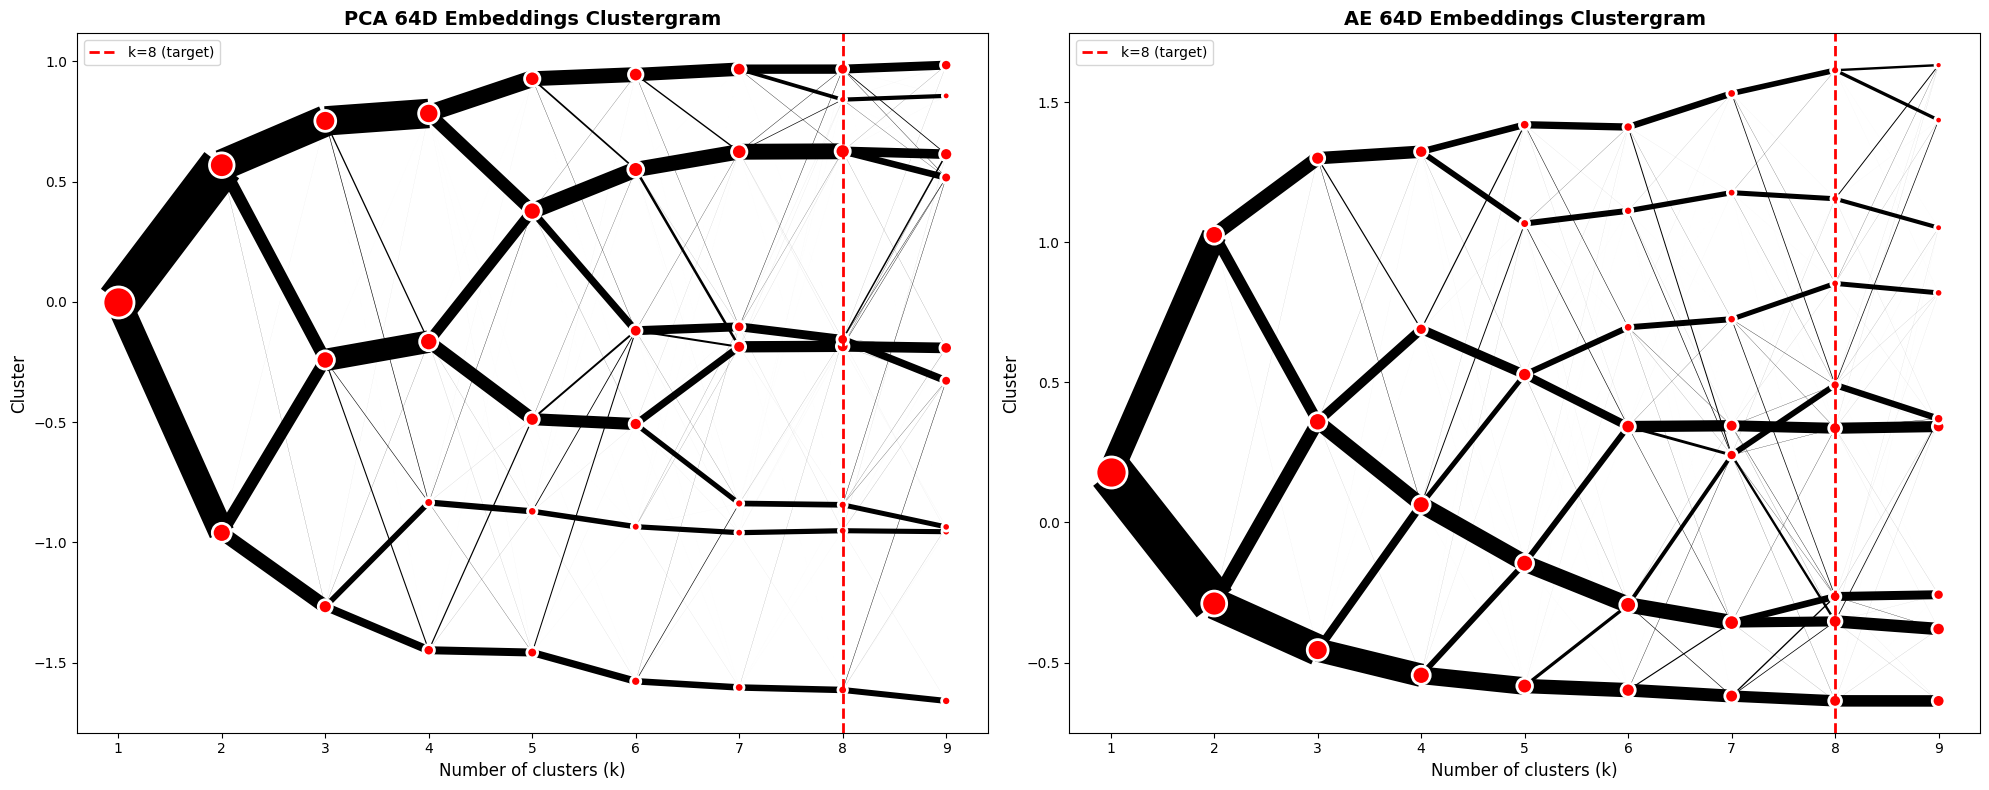


✓ Clustergrams saved to ./plots/geodemo_clustering_median_run//clustergram_comparison_64d.png


In [4]:
# Make a clustergram for PCA and AE embeddings
print("\nGenerating PCA clustergram...")
cgram_pca = clustergram.Clustergram(range(1,10), n_init=10, random_state=random_seed)
cgram_pca.fit(pca_latent_df)

# Create clustergram for AE embeddings  
print("Generating AE clustergram...")
cgram_ae = clustergram.Clustergram(range(1,10), n_init=10, random_state=random_seed)
cgram_ae.fit(ae_latent_df)

# Plot both clustergrams side by side
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# PCA clustergram
cgram_pca.plot(ax=axes[0], figsize=None)
axes[0].set_title(f'PCA {target_dim}D Embeddings Clustergram', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of clusters (k)', fontsize=12)
axes[0].set_ylabel('Cluster', fontsize=12)
axes[0].axvline(x=n_clusters, color='red', linestyle='--', linewidth=2, label=f'k={n_clusters} (target)')
axes[0].legend()

# AE clustergram
cgram_ae.plot(ax=axes[1], figsize=None)
axes[1].set_title(f'AE {target_dim}D Embeddings Clustergram', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of clusters (k)', fontsize=12)
axes[1].set_ylabel('Cluster', fontsize=12)
axes[1].axvline(x=n_clusters, color='red', linestyle='--', linewidth=2, label=f'k={n_clusters} (target)')
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{output_dir}/clustergram_comparison_{target_dim}d.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Clustergrams saved to {output_dir}/clustergram_comparison_{target_dim}d.png")

In [7]:
output_dir

'./plots/geodemo_clustering_median_run/'

## K-Means Clustering


Performing AE K-Means clustering (k=8, n_init=100)...
  Time: 100.6s
  Inertia: 144511.52
  Iterations: 20
  Saved to ./plots/geodemo_clustering_median_run//data/kmeans_ae_64d_k8_n100.joblib
Performing PCA K-Means clustering (k=8, n_init=100)...
  Time: 77.0s
  Inertia: 211990.88
  Iterations: 27
  Saved to ./plots/geodemo_clustering_median_run//data/kmeans_pca_64d_k8_n100.joblib

Cluster assignments saved to ./plots/geodemo_clustering_median_run//data/cluster_assignments_64d_k8_n100.csv

Cluster distributions:

PCA clusters:
pca_cluster
0    14326
1    27588
2    26127
3    17693
4    12089
5    44673
6    15622
7    30762
Name: count, dtype: int64

AE clusters:
ae_cluster
0    14015
1    25367
2    31748
3    36288
4    19878
5    31771
6    14231
7    15582
Name: count, dtype: int64


In [ ]:
import time
from datetime import datetime, timedelta

n_inits = 10000
clustering_file = f"{output_dir}/data/cluster_assignments_{target_dim}d_k{n_clusters}_n{n_inits}.csv"
pca_model_file = f"{output_dir}/data/kmeans_pca_{target_dim}d_k{n_clusters}_n{n_inits}.joblib"
ae_model_file = f"{output_dir}/data/kmeans_ae_{target_dim}d_k{n_clusters}_n{n_inits}.joblib"

# Ensure output directory exists
os.makedirs(os.path.dirname(clustering_file), exist_ok=True)

# --- AE Clustering (check separately) ---
if os.path.exists(ae_model_file):
    print(f"\nLoading existing AE clustering from {ae_model_file}...")
    kmeans_ae = joblib.load(ae_model_file)
    ae_clusters = kmeans_ae.predict(ae_latent_df)
    print(f"  KMeans AE - Inertia: {kmeans_ae.inertia_:.2f}")
else:
    estimated_finish = datetime.now() + timedelta(seconds=n_inits)
    print(f"\nPerforming AE K-Means clustering (k={n_clusters}, n_init={n_inits})...")
    print(f"  Estimated finish: {estimated_finish.strftime('%H:%M:%S')}")
    start_time = time.time()
    kmeans_ae = KMeans(n_clusters=n_clusters, random_state=random_seed, n_init=n_inits, max_iter=1000)
    ae_clusters = kmeans_ae.fit_predict(ae_latent_df)
    ae_time = time.time() - start_time
    print(f"  Time: {ae_time:.1f}s")
    print(f"  Inertia: {kmeans_ae.inertia_:.2f}")
    print(f"  Iterations: {kmeans_ae.n_iter_}")
    joblib.dump(kmeans_ae, ae_model_file)
    print(f"  Saved to {ae_model_file}")

# --- PCA Clustering (check separately) ---
if os.path.exists(pca_model_file):
    print(f"Loading existing PCA clustering from {pca_model_file}...")
    kmeans_pca = joblib.load(pca_model_file)
    pca_clusters = kmeans_pca.predict(pca_latent_df)
    print(f"  KMeans PCA - Inertia: {kmeans_pca.inertia_:.2f}")
else:
    estimated_finish = datetime.now() + timedelta(seconds=n_inits)
    print(f"Performing PCA K-Means clustering (k={n_clusters}, n_init={n_inits})...")
    print(f"  Estimated finish: {estimated_finish.strftime('%H:%M:%S')}")
    start_time = time.time()
    kmeans_pca = KMeans(n_clusters=n_clusters, random_state=random_seed, n_init=n_inits, max_iter=1000)
    pca_clusters = kmeans_pca.fit_predict(pca_latent_df)
    pca_time = time.time() - start_time
    print(f"  Time: {pca_time:.1f}s")
    print(f"  Inertia: {kmeans_pca.inertia_:.2f}")
    print(f"  Iterations: {kmeans_pca.n_iter_}")
    joblib.dump(kmeans_pca, pca_model_file)
    print(f"  Saved to {pca_model_file}")

# --- Create/Update clusters_df ---
clusters_df = pd.DataFrame({
    'pca_cluster': pca_clusters,
    'ae_cluster': ae_clusters,
    'oac_supergroup': oac['Supergroup8'].values
}, index=df_census.index)

# Save combined results
clusters_df.to_csv(clustering_file)
print(f"\nCluster assignments saved to {clustering_file}")
print("\nCluster distributions:")
print("\nPCA clusters:")
print(clusters_df['pca_cluster'].value_counts().sort_index())
print("\nAE clusters:")
print(clusters_df['ae_cluster'].value_counts().sort_index())


Performing AE K-Means clustering (k=8, n_init=10000)...
  Estimated finish: 15:55:54


In [19]:
import torch
print(torch.version.cuda)

12.8
